# 1. Setting Up the Environment for Advanced Analysis

In [19]:
# Importing all necessary libraries for advanced modeling, analysis, and plotting
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Loading the clean data and the preprocessor that was fitted on the full dataset
df = pd.read_csv('data/processed/cleaned_laptops.csv')
preprocessor = joblib.load('models/preprocessor.joblib')

# Defining our features (X) and target variable (y)
X = df.drop(columns=['price', 'name'])
y = df['price']

# Applying the already-fitted preprocessor to our entire feature set for analysis
# This is necessary for visualizations like PCA
X_processed = preprocessor.transform(X)

print("Finished setting up the environment and loading all necessary files.")

Finished setting up the environment and loading all necessary files.


# 2. Visualizing High-Dimensional Data with PCA

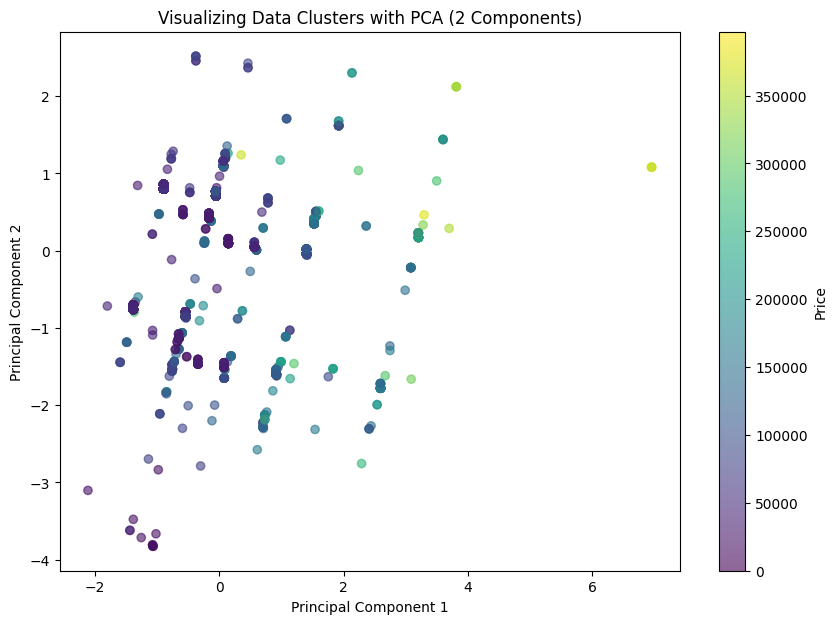

In [20]:
# Reducing the many features down to 2 principal components for a 2D plot
# This helps us visualize the overall structure of the data.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Plotting the PCA results, coloring the points by price to see if there are patterns
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(label='Price')
plt.title('Visualizing Data Clusters with PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('reports/figures/pca_visualization.png')
plt.show()

# 3. Creating and Training the Final Model Pipeline

In [21]:
# This is the most robust way to build a model for deployment.
print("Training the final pipeline on log-transformed prices...")
y_log = np.log1p(y)

# We are defining the model with its best parameters, as found from earlier tuning.
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# We are creating a full Pipeline object that contains BOTH the preprocessor and the model.
# This is the best practice for saving a model, as it bundles all steps together.
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', final_model)
])

# We are fitting the entire pipeline on the complete dataset (X and y_log).
full_pipeline.fit(X, y_log)

# Saving the ENTIRE pipeline to a single file. This object now contains everything needed for prediction.
joblib.dump(full_pipeline, 'models/final_full_pipeline.joblib')

print("Final, complete pipeline has been trained and saved successfully.")

Training the final pipeline on log-transformed prices...
Final, complete pipeline has been trained and saved successfully.


# 4. Analyzing the Final Model's Learning Curve

Generating the learning curve...


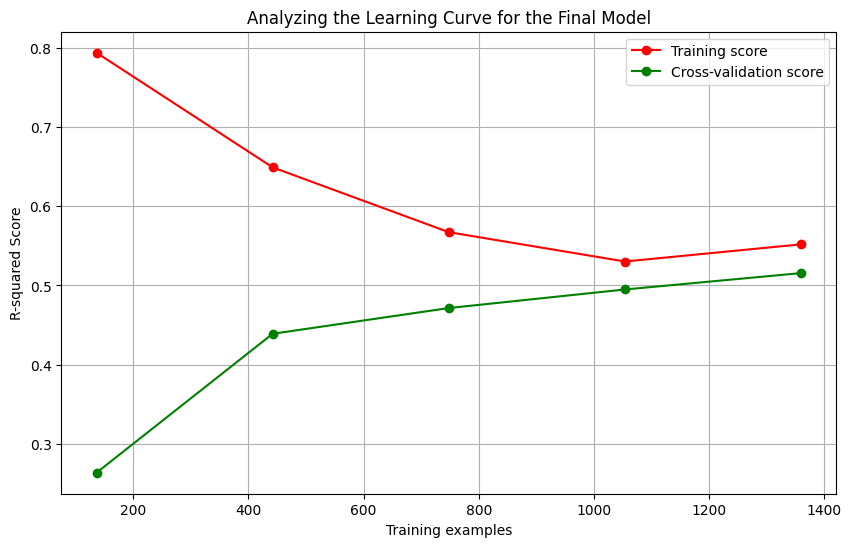

In [22]:
# Generating the learning curve for our final pipeline to check for overfitting.
# This plot shows how the model's performance changes as it sees more data.
print("Generating the learning curve...")
train_sizes, train_scores, test_scores = learning_curve(
    full_pipeline, X, y_log, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring="r2"
)

# Calculating mean scores for plotting
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plotting the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.title('Analyzing the Learning Curve for the Final Model')
plt.xlabel("Training examples")
plt.ylabel("R-squared Score")
plt.legend(loc="best")
plt.grid(True)
plt.savefig('reports/figures/learning_curve.png')
plt.show()

# 5. Extracting and Visualizing Feature Importances

--- Top 10 Most Important Features ---
                      Feature  Importance
0                 num__ram_gb    0.625003
2       num__screen_size_inch    0.130123
1                 num__ssd_gb    0.120088
4  cat__processor_brand_Apple    0.096785
5  cat__processor_brand_Intel    0.013289
3    cat__processor_brand_AMD    0.009211
6  cat__processor_brand_Other    0.005500


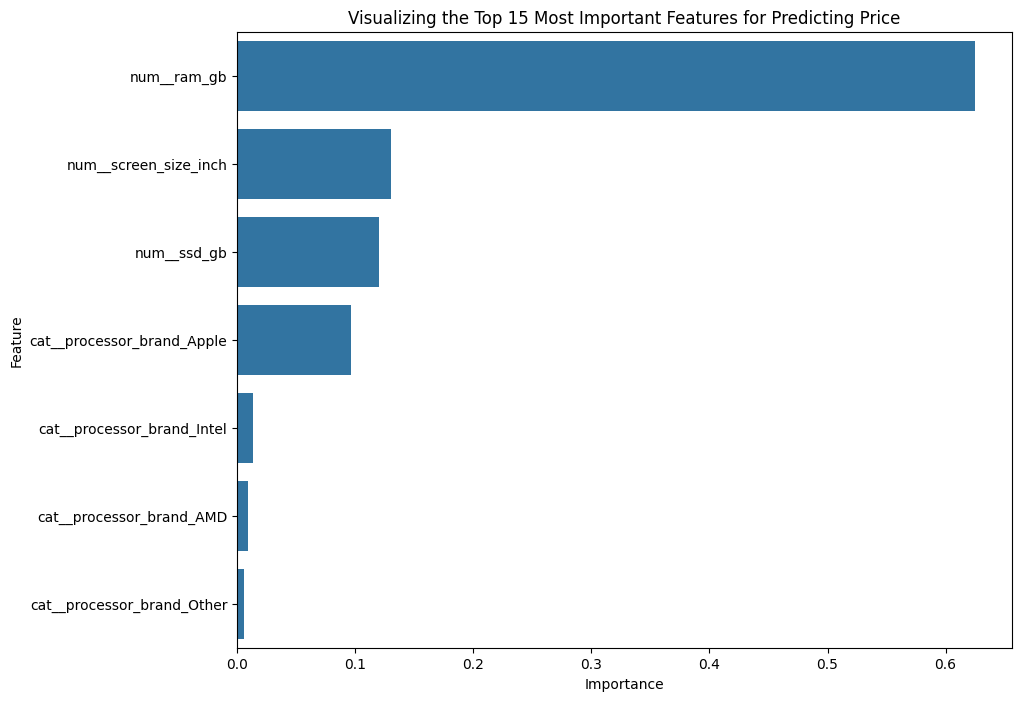


'feature_importance.png' has been saved to the 'reports/figures' folder.


In [23]:
# Extracting the feature names from the preprocessor step of our pipeline
feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Extracting the importance scores from the regressor step of our pipeline
importances = full_pipeline.named_steps['regressor'].feature_importances_

# Creating a DataFrame to view and sort the feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Top 10 Most Important Features ---")
print(importance_df.head(10))

# Visualizing the feature importances to include in the report's conclusion
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Visualizing the Top 15 Most Important Features for Predicting Price')
plt.savefig('reports/figures/feature_importance.png')
plt.show()

print("\n'feature_importance.png' has been saved to the 'reports/figures' folder.")